# 1.决策树


## 1.1 决策树原理

### 1.1.1如何切分特征

目标：通过一种衡量标准计算不同特征进行分支选择后的情况，找出最好的那个当根节点以此类推



### 1.1.2衡量标准-熵

熵：随机变量不确定性的度量（表明物体内部混乱程度）

公式：$H_x = - \sum p_i * \log p_i$

$p_i$ 表示分类后第i个类别数占总计的比例

- 熵值大，不确定性度量高。
    - p = 0.5，H(p) = 1，随机变量不确定性最高
    - p = 0或1，H(p) = 0，随机变量完全没有不确定性

集合A [1,1,1,1,1,1,1,2,2]

集合B [1,2,3,4,5,6,7,8,9]

A集合熵值更低，分类任务中 我们希望通过节点分支后数据类别的熵值降低。

信息增益：表示特征X使得类Y的不确定性减少的程度——分类后的转移性，希望分类结果是同类在一起



### 1.1.3决策树构造

#### 1.1.3.1决策树构造步骤
- 计算原始熵值
- 分别计算各特征划分后的熵值（加权熵值）
- 计算各特征的熵值差——信息增益，信息增益最大的特征选做根节点
- 重复以上步骤，通过信息增益计算接下的节点

**决策树算法**
- ID3：信息增益，不适合处理类似ID分类较多的特征
- C4.5：信息增益率，解决ID3问题，考虑自身熵。（信息增益/自身熵值）
- CART：使用GINI系数当衡量标准

**连续值处理方法**

- 贪婪算法
    - 排序
    - 使用二分法，分割成TaxIn <= x,TaxIn>80；
    - 选择某个切分点使信息增益最大

#### 1.1.3.2决策树剪枝策略
- 决策树过拟合风险很大，理论上可以完全分得开数据。
- 剪枝策略：预剪枝，后剪枝
- 预剪枝：便建立决策树边进行剪枝的操作（更实用）
- 后剪枝：建立完成决策树后进行剪枝的操作

预剪枝：限制深度，叶子节点个数/样本数，信息增益量等

后剪枝：通过一定的衡量标准——叶子节点越多，损失越大

#### 1.1.3.3决策树使用

- 分类：用众数判断
- 回归：用方差判断分类是否合理，用最终的平均值当做预测值

## 1.2 决策树实例

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from urllib3.contrib.emscripten import fetch
%matplotlib inline
import matplotlib
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
import warnings
warnings.filterwarnings('ignore')

In [13]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

iris = load_iris()
X = iris.data[:,2:]
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2)

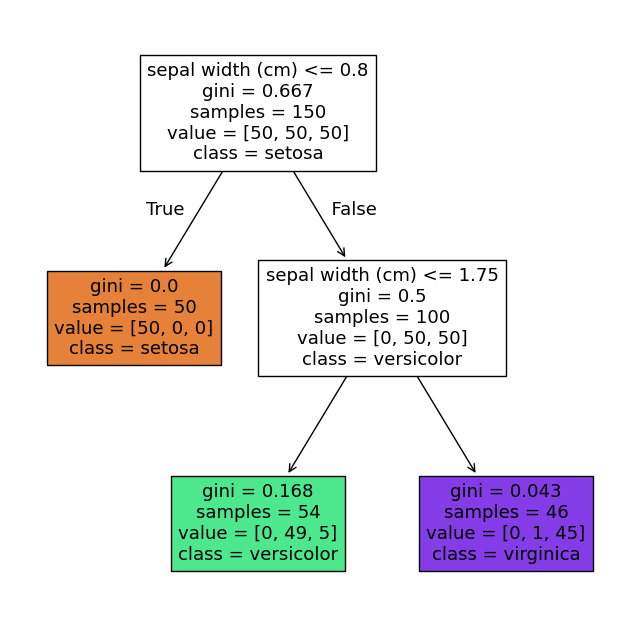

In [14]:
fig = plt.figure(figsize=(8,8))
_ = tree.plot_tree(
    tree_clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
fig.savefig('decision_tree.png')

想知道花瓣长5cm宽1.5厘米的花瓣属于哪一类

In [16]:
tree_clf.predict_proba([[5,1.5]])

array([[0.        , 0.90740741, 0.09259259]])

In [17]:
tree_clf.predict([[5,1.5]])


array([1])


DecislonTreeClasslfler 存在一些参数限制决策树形状
- min_samples_split(节点在分割之前必须具有的最小样本)
- min_samples_leaf(叶子节点必须有最小样本数)
- max_lead_nodes(叶子节点的最大数量)
- max_features(每个节点处评估用户拆分的最大特征数)
- max_depth(树最大的深度)

# 2.集成算法

## 2.1集成算法分类
**Ensemble learning**

- 目的： 让机器学习效果更好
- Bagging：训练多个分类器取平均 $f(x) = 1/M \sum f_m(x)$
- Boosting：弱学习器开始加强，通过加权进行训练（加入一棵树，比原来强）
- Stacking：聚合多个分类或回归模型

**Bagging**

- 并行训练一堆分类器（并联电路）
- 典型代表：**随机**森林——数据随机采样，特征随机选择
- 随机森林可以处理高维度数据，不用做特征选择。可解释性很高，并且容易做成并行化方法，速度块。
- 随机森林可进行特征选择：通过破坏特征来计算前后错误率差距，差距越大越重要。
- 理论上树的效果越多越好，但实际基本超过一定数量的树后，准确率就会上下浮动

**Boosting**

- 提升算法
- $F_m (x) = F_{m-1}(x) + argmin_h \sum L(y_i,F_{m-1} (x_i) + h(x_i))$
- AdaBoost：根据前一次的分类效果调整数据权重
    - 数据数据在这一次分错，下一次就会给它更大权重
    - 最终结果：每个分类器根据自身准确性确定各自权重再取平均
- XgBoost:B树弥补A树预测失效的残差（串联电路）

**Stacking**

- 步骤一：使用不同模型得到结果
- 步骤二：将步骤一得到的结果做为模型的输入进行训练
- 可以堆叠各种各样的分类器：KNN,SVM,RF等等
- 耗时间



## 2.2 Bossting策略



### 2.2.1 硬投票与软投票

- 硬投票：直接比较各分类结果，少数服从多数
- 软投票：加权比较分类结果



**硬投票实验**

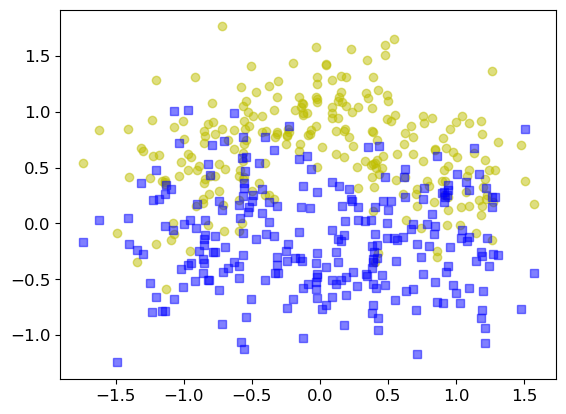

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
# 构建难度较大数据集，包含大量重叠
X,y = make_moons(n_samples=500, noise=0.3,random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,  random_state=42)
plt.plot(X[:,0][y == 0],X[:,1][y == 0],'yo',alpha=.5)
plt.plot(X[:,0][y == 0],X[:,1][y == 1],'bs',alpha=.5)

In [69]:
from sklearn.ensemble import RandomForestClassifier,VotingClassifier # 投票器-硬投票
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# 算法实例化
log = LogisticRegression()
rf = RandomForestClassifier()
svm = SVC()

voting_clf = VotingClassifier(estimators=[('lr',log),('rf',rf),('svc',svm)], voting='hard')

In [70]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [71]:
from sklearn.metrics import accuracy_score
for clf in [log,rf,svm,voting_clf]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__,accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.888
SVC 0.896
VotingClassifier 0.904



**软投票实验**


In [72]:

from sklearn.ensemble import RandomForestClassifier,VotingClassifier # 投票器-硬投票
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# 算法实例化
log_clf = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(probability=True,random_state=42)

voting_clf_soft = VotingClassifier(estimators=[('lr',log_clf),('rf',rf_clf),('svc',svm_clf)], voting='soft')
voting_clf_soft.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
for clf in [log_clf,rf_clf,svm_clf,voting_clf_soft]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__,accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.92


### 2.2.2 AdaBoost

In [73]:
# 画决策边界
from matplotlib.colors import ListedColormap
def plot_decision_boundary(clf, X, y,axes = [-1.5,2.5,-1,1.5],alpha = 0.5,contour = True): # contour 画轮廓等高线
    x1s = np.linspace(axes[0],axes[1],100)
    x2s = np.linspace(axes[2],axes[3],100)
    x1,x2 = np.meshgrid(x1s,x2s)
    X_new = np.c_[x1.ravel(),x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1,x2,y_pred, alpha = 0.3,cmap=custom_cmap,)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1,x2,y_pred,linewidths=0.5,cmap = custom_cmap2,alpha=0.8)
    plt.plot(X[:,0][y == 0],X[:,1][y == 0],'yo',alpha=.5)
    plt.plot(X[:,0][y == 0],X[:,1][y == 1],'bs',alpha=.5)
    plt.axis(axes)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

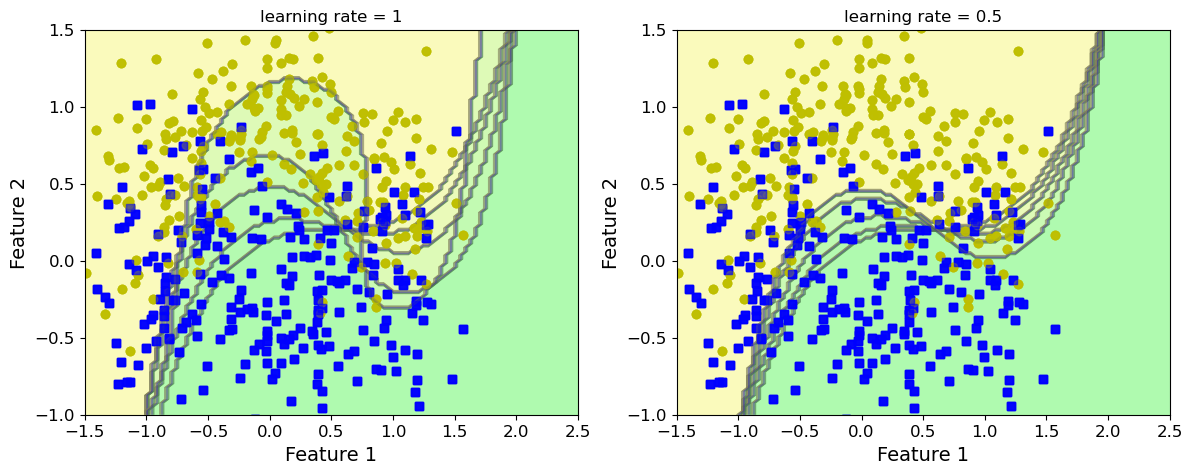

In [76]:
# adaboost原理仿造
from sklearn.svm import SVC
m = len(X_train)
plt.figure(figsize=(14,5))
for subplot,learning_rate in ((121,1),(122,0.5)):
    sample_weights = np.ones(m)
    plt.subplot(subplot)
    for i in range(5):
        svm = SVC(kernel='rbf',C=0.05)
        svm.fit(X_train,y_train,sample_weight=sample_weights)
        y_pred = svm.predict(X_train)
        sample_weights[y_pred != y_train] *= (1+learning_rate)
        plot_decision_boundary(svm,X,y,alpha = 0.2)
        plt.title(f'learning rate = {learning_rate}' )

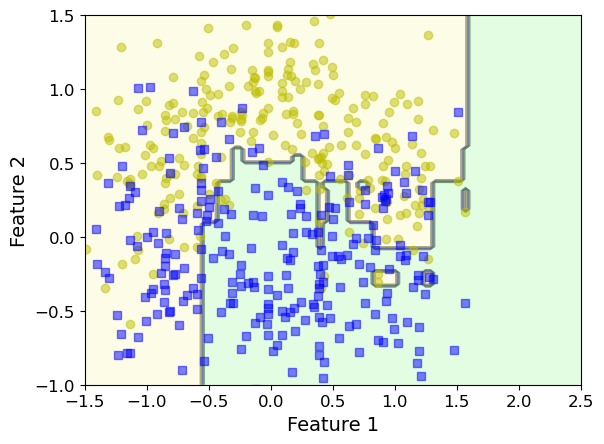

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=2),
                         n_estimators=200,
                         learning_rate=0.5,
                         random_state=42
                   )
ada.fit(X_train,y_train)
plot_decision_boundary(ada,X,y)

### 2.2.3 GDBT
梯度提升决策树

一代：GDBT - sklearn

二代：XGBoost

三代：lightGBM (竞赛用)


In [88]:
np.random.seed(42)
X = np.random.rand(100,1) - 0.5
y = 3*X[:,0]**2 + 0.05*np.random.randn(100)
from sklearn.tree import DecisionTreeRegressor
tree_regl = DecisionTreeRegressor()
tree_regl.fit(X,y)
y2 = y  - tree_regl.predict(X)
tree_regl2 = DecisionTreeRegressor()
tree_regl2.fit(X,y2)
y3 = y2  - tree_regl.predict(X)
tree_regl3 = DecisionTreeRegressor()
tree_regl3.fit(X,y3)
X_new = np.array([[0.8]])
y_pred = sum(tree.predict(X_new) for tree in (tree_regl,tree_regl2,tree_regl3))
print(y_pred)

[0.]


In [90]:
# gbdt演示
from sklearn.ensemble import GradientBoostingRegressor
gbdt = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42,
    max_depth=3
)
gbdt.fit(X,y)
gbdt1 = GradientBoostingRegressor(
    n_estimators=3,
    learning_rate=0.1,
    random_state=41,
    max_depth=3
)
gbdt1.fit(X,y)
gbdt2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=41,
    max_depth=3
)
gbdt2.fit(X,y)


[ 5.15728987e-02  5.94479790e-01  1.66051606e-01 -7.01779562e-02
  3.43985933e-01  3.72874939e-01  6.59764984e-01  3.76341398e-01
 -9.75194335e-03  1.04794741e-01  7.35287787e-01  6.78883363e-01
  3.05066318e-01  2.73909733e-01  3.08559932e-01  3.49130363e-01
  7.98606436e-02 -1.45444646e-02 -5.71096619e-03  5.75800683e-02
  5.23392240e-02  4.02946793e-01  1.29867214e-01  4.18481141e-02
 -6.49789982e-02  2.22943721e-01  2.53451786e-01 -3.95060058e-02
  1.75570720e-02  6.37324227e-01  1.29006981e-01  3.34391950e-01
  5.80417870e-01  6.00772381e-01  5.54501010e-01  2.84001079e-01
  1.17538848e-01  6.08765289e-01  9.22073759e-02  2.58225391e-02
  4.26829699e-01 -5.83641153e-02  7.07523289e-01  5.40226226e-01
  2.14112889e-01  3.37711060e-02  1.76497872e-01 -6.88843767e-02
  3.58884053e-02  4.07472924e-01  6.12002352e-01  1.98779325e-01
  5.84460527e-01  4.42492127e-01 -4.87799540e-02  5.37361759e-01
  4.54900077e-01  3.00958881e-01  5.74483445e-01  1.69025200e-01
 -1.98442712e-03  1.40740

## 2.3 Bagging策略

- 首先对训练数据集多次采样，保证每次得到的采样数据不同
- 同一种方法训练多个模型
- 预测时需要得到所有模型结果再集成

### 2.3.1Bagging与Tree对比

In [44]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
import os
os.environ['JOBLIB_TEMP_FOLDER'] = 'C:/temp_joblib' # 确保C:/temp_joblib存在且是全英文路径
# 构建难度较大数据集，包含大量重叠
X,y = make_moons(n_samples=500, noise=0.3,random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,  random_state=42)
bag = BaggingClassifier(DecisionTreeClassifier(),
                        n_estimators=500,
                        max_samples=100,
                        bootstrap=True, # 有放回随机采样
                        n_jobs=-1, #使用全部cpu
                        random_state=42
                        )
bag.fit(X_train, y_train)
y_pred = bag.predict(X_test)


In [48]:
accuracy_score(y_test,y_pred)

0.904

In [50]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
accuracy_score(y_test,y_pred_tree)

0.856

### 2.3.2决策边界

- 集成与传统方法对比

In [55]:
# 画决策边界
from matplotlib.colors import ListedColormap
def plot_decision_boundary(clf, X, y,axes = [-1.5,2.5,-1,1.5],alpha = 0.5,contour = True): # contour 画轮廓等高线
    x1s = np.linspace(axes[0],axes[1],100)
    x2s = np.linspace(axes[2],axes[3],100)
    x1,x2 = np.meshgrid(x1s,x2s)
    X_new = np.c_[x1.ravel(),x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1,x2,y_pred, alpha = 0.3,cmap=custom_cmap,)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1,x2,y_pred,linewidths=0.5,cmap = custom_cmap2,alpha=0.8)
    plt.plot(X[:,0][y == 0],X[:,1][y == 0],'yo',alpha=.5)
    plt.plot(X[:,0][y == 0],X[:,1][y == 1],'bs',alpha=.5)
    plt.axis(axes)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

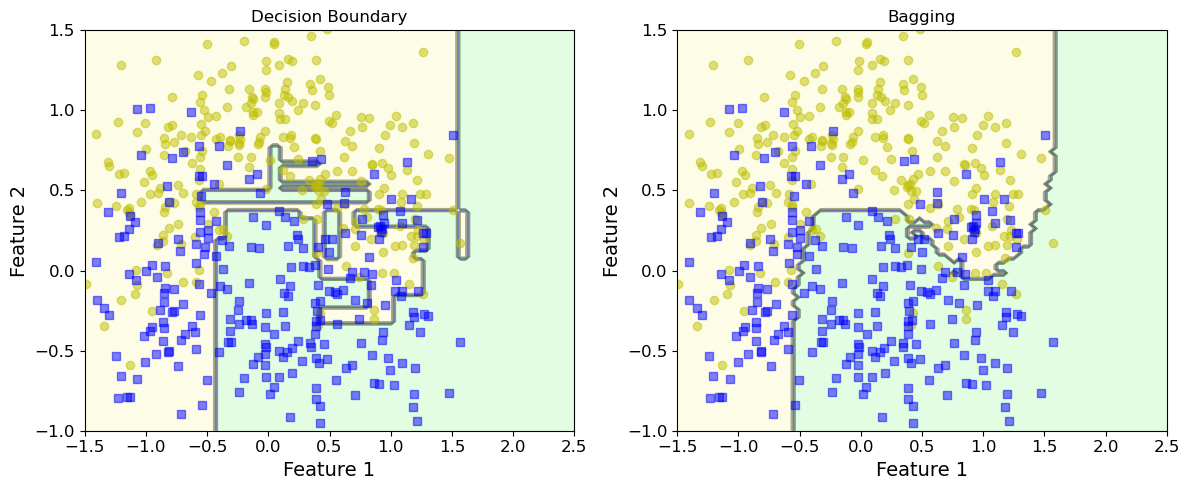

In [56]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_decision_boundary(tree, X, y)
plt.title('Decision Boundary')
plt.subplot(1,2,2)
plot_decision_boundary(bag, X, y)
plt.title('Bagging')
plt.tight_layout()
plt.savefig('decision_boundary.png')


### 2.3.3OOB策略

- out of bag


In [57]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
import os
os.environ['JOBLIB_TEMP_FOLDER'] = 'C:/temp_joblib' # 确保C:/temp_joblib存在且是全英文路径
# 构建难度较大数据集，包含大量重叠
X,y = make_moons(n_samples=500, noise=0.3,random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,  random_state=42)
bag = BaggingClassifier(DecisionTreeClassifier(),
                        n_estimators=500,
                        max_samples=100,
                        bootstrap=True, # 有放回随机采样
                        n_jobs=-1, #使用全部cpu
                        random_state=42,
                        oob_score=True,
                        )
bag.fit(X_train, y_train)
bag.oob_score_ # 验证集结果，不需要交叉验证

0.9253333333333333

In [58]:
y_pred = bag.predict(X_test)
accuracy_score(y_test,y_pred)

0.904

### 2.3.4 随机森林

获得每个特征重要性结果，在sklearn中是看每个特征的深度（看特征离跟根节点的远近）

In [59]:
bag.oob_decision_function_ # 检查每个样本分类概率

array([[0.35579515, 0.64420485],
       [0.43513514, 0.56486486],
       [1.        , 0.        ],
       [0.01030928, 0.98969072],
       [0.03174603, 0.96825397],
       [0.07672634, 0.92327366],
       [0.39189189, 0.60810811],
       [0.06145251, 0.93854749],
       [0.92689295, 0.07310705],
       [0.88205128, 0.11794872],
       [0.59850374, 0.40149626],
       [0.04896907, 0.95103093],
       [0.7565445 , 0.2434555 ],
       [0.81377551, 0.18622449],
       [0.88528678, 0.11471322],
       [0.07407407, 0.92592593],
       [0.04738155, 0.95261845],
       [0.92051282, 0.07948718],
       [0.69974555, 0.30025445],
       [0.94358974, 0.05641026],
       [0.06100796, 0.93899204],
       [0.224     , 0.776     ],
       [0.9125964 , 0.0874036 ],
       [0.98746867, 0.01253133],
       [0.95967742, 0.04032258],
       [0.        , 1.        ],
       [0.94255875, 0.05744125],
       [1.        , 0.        ],
       [0.03466667, 0.96533333],
       [0.7020202 , 0.2979798 ],
       [0.

In [60]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
iris = load_iris()
rf = RandomForestClassifier(n_estimators=500,n_jobs=-1)
rf.fit(iris['data'], iris['target'])
for name,score in zip(iris['feature_names'],rf.feature_importances_):
    print(name,score)

sepal length (cm) 0.09272647967212172
sepal width (cm) 0.025186606086657022
petal length (cm) 0.44010075640066626
petal width (cm) 0.4419861578405549


### 2.3.5 Mnist 查看特征重要性（图像数据）

In [66]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, parser='auto')

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000246DA526AD0>>
Traceback (most recent call last):
  File "D:\program\anaconda30721\envs\deeplearning\lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt



In [ ]:
rf = RandomForestClassifier(n_estimators=500,n_jobs=-1)
rf.fit(mnist.data, mnist.target)

In [ ]:
rf.feature_importances_.shape

In [ ]:
def plot_digit(data):
    image = data.reshape(28,28)
    plt.imshow(image, cmap=plt.cm.hot)
    plt.axis('off')
plot_digit(rf.feature_importances_)
char = plt.colorbar(ticks=[rf.feature_importances_.min(),rf.feature_importances_.max()])
char.ax.set_yticklabels(['not important','very important'])

## 2.4提前停止策略

In [95]:
from sklearn.metrics import mean_squared_error
X_train,X_val,y_train,y_val = train_test_split(X,y,random_state=42)
gbdt2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=41,
    max_depth=3
)
gbdt2.fit(X_train,y_train)
errors =[mean_squared_error(y_val,y_pred) for y_pred in gbdt2.staged_predict(X_val)]
best_n_estimator = np.argmin(errors)

gbdt2_best = GradientBoostingRegressor(
    n_estimators=best_n_estimator,
    learning_rate=0.1,
    random_state=41,
    max_depth=3
)
gbdt2.fit(X_train,y_train)

min_error = np.min(errors)
print(min_error)


0.002954160742523786


Text(0.5, 1.0, 'validation error')

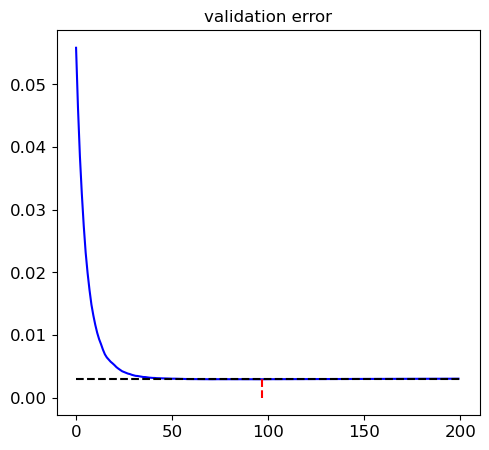

In [94]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(errors,'b-')
plt.plot([best_n_estimator,best_n_estimator],[0,min_error],'r--')
plt.plot([0,200],[min_error,min_error],'k--')
plt.title('validation error')